# 1. Prepare Test set

In [ ]:
import os
import random
import numpy as np
import torch
from torch.utils.data import DataLoader

from build_dataset.build_dataset import get_samples, MelNPYDataset 
from build_dataset.seed import set_seed
from models.fusion_mel import DualMelFusion

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

PROCESSED_PATH = "./gtzan_mel_3s"
PATH = './best_model.pt'

SEED = 42
BATCH_SIZE = 16
NUM_CLASSES = 10
NUM_WORKERS = 0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

test_samples, class_map = get_samples(PROCESSED_PATH, "test")

test_ds = MelNPYDataset(test_samples, train=False)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True, worker_init_fn=seed_worker)


# 2. Run casual prediction

In [ ]:
model = DualMelFusion(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(PATH))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for mel, y in test_loader:

        mel = mel.to(device)

        out = model(mel)
        preds = out.argmax(dim=1)

        y_true += y.cpu().numpy().tolist()
        y_pred += preds.cpu().numpy().tolist()

labels = list(class_map.keys())

              precision    recall  f1-score   support

       blues     0.8543    0.8500    0.8521       200
   classical     0.8964    0.9950    0.9431       200
     country     0.7488    0.8000    0.7735       190
       disco     0.8281    0.9150    0.8694       200
      hiphop     0.9114    0.7200    0.8045       200
        jazz     0.9403    0.9450    0.9426       200
       metal     0.9495    0.9400    0.9447       200
         pop     0.8063    0.8950    0.8483       200
      reggae     0.8274    0.8150    0.8212       200
        rock     0.7692    0.6500    0.7046       200

    accuracy                         0.8528      1990
   macro avg     0.8532    0.8525    0.8504      1990
weighted avg     0.8537    0.8528    0.8508      1990



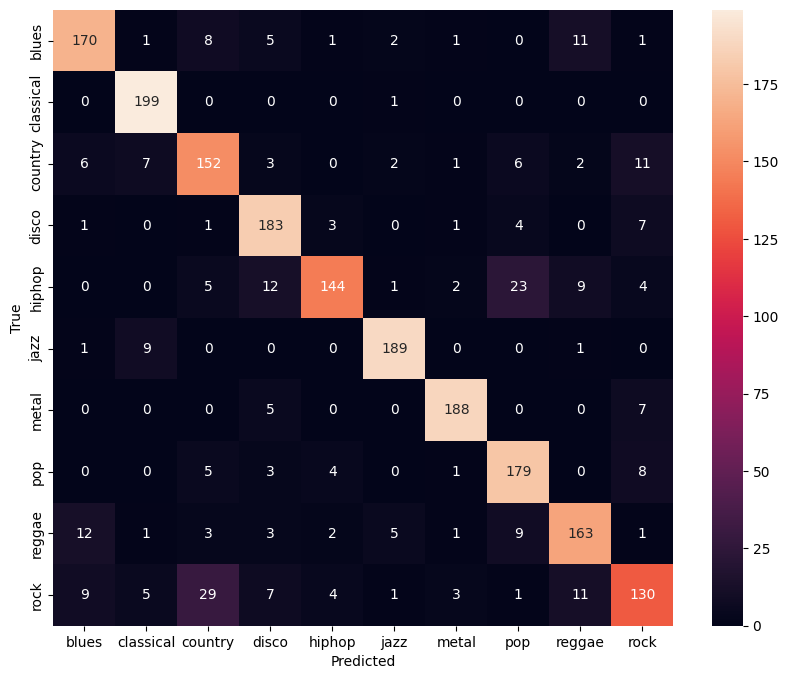

In [ ]:

print(classification_report(y_true, y_pred, target_names=labels, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# 3. Run prediction by "grand" sample

In [ ]:
from collections import defaultdict

def get_song_id(path):
    name = os.path.basename(path)
    return name.split("_seg")[0]

song_groups = defaultdict(list)

for path, label in test_samples:
    song_id = get_song_id(path)
    song_groups[song_id].append((path, label))

y_true = []
y_pred = []

for song_id, segments in song_groups.items():

    preds = []

    for path, label in segments:

        mel = np.load(path)
        mel = torch.tensor(mel, dtype=torch.float32)

        if mel.dim() == 2:
            mel = mel.unsqueeze(0)

        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        crop_size = 120
        T = mel.shape[-1]
        start = (T - crop_size) // 2
        mel = mel[:, :, start:start + crop_size]

        mel = mel.unsqueeze(0).to(device)

        with torch.no_grad():
            out = model(mel)

        pred = out.argmax(dim=1).item()
        preds.append(pred)

    # majority vote
    final_pred = max(set(preds), key=preds.count)

    y_pred.append(final_pred)
    y_true.append(label)

              precision    recall  f1-score   support

       blues     0.8636    0.9500    0.9048        20
   classical     0.8696    1.0000    0.9302        20
     country     0.8095    0.8947    0.8500        19
       disco     0.9524    1.0000    0.9756        20
      hiphop     1.0000    0.8000    0.8889        20
        jazz     1.0000    0.9500    0.9744        20
       metal     1.0000    0.9500    0.9744        20
         pop     0.8261    0.9500    0.8837        20
      reggae     0.8947    0.8500    0.8718        20
        rock     0.8750    0.7000    0.7778        20

    accuracy                         0.9045       199
   macro avg     0.9091    0.9045    0.9032       199
weighted avg     0.9096    0.9045    0.9034       199



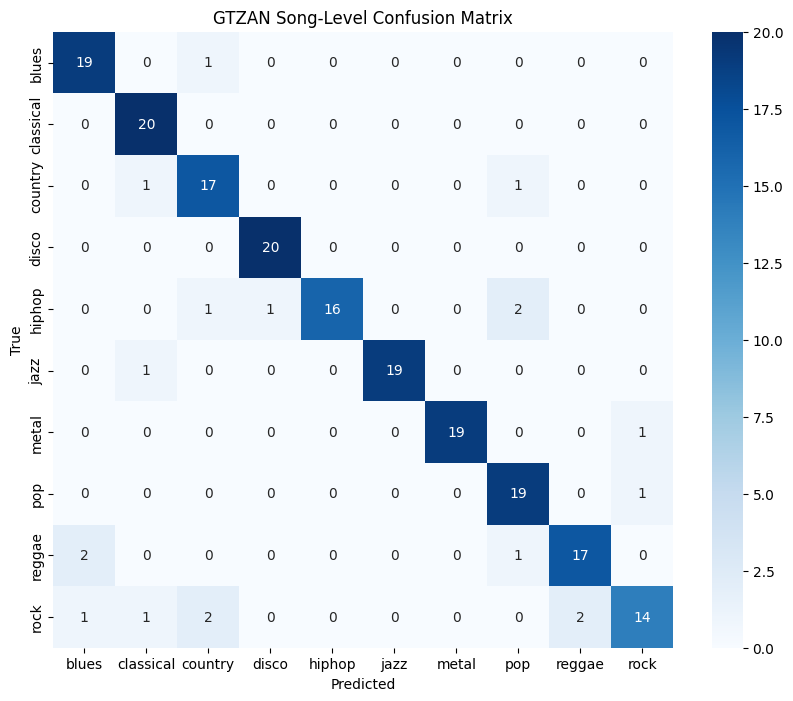

In [ ]:
print(classification_report(y_true, y_pred, target_names=labels, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("GTZAN Song-Level Confusion Matrix")
plt.show()